# Chapter 12: Floer Homology

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Chapter 12, printed pp. 487-530; PDF pp. 502-545. Sections 12.1-12.7 were read with `pdftotext` for orientation. The prose, diagrams, computations, and checks here are original teaching material.

## Chapter Goal

Build a computational mental model for Hamiltonian Floer theory: periodic orbits become generators, connecting cylinders become a differential, action gives a filtration, pair-of-pants surfaces multiply classes, and the same formalism feeds Seidel actions, Donaldson categories, and vortex-style moment-map Floer theories.

## Computational Translation Guide

| Source concept | Notebook model | What to inspect |
| --- | --- | --- |
| Hamiltonian periodic orbits | finite generator table with action and Conley-Zehnder-style degree | generators are graded and ordered by action |
| Floer connecting cylinders | directed edges between generators | edge energy equals action drop |
| cochain/chain differential | mod 2 boundary matrices | `d1 @ d2 == 0` and signed cancellation |
| compactness and finiteness | finite support windows and broken-trajectory endpoints | only finitely many generators under a cutoff; broken pairs cancel |
| continuation and PSS maps | small matrices linking two regular choices and a quantum ring | continuation commutes with PSS and product |
| pair-of-pants product | `QH(CP1)` toy multiplication with `H*H=q` | associativity, unit, and degree bookkeeping |
| Poincare duality | action/sign reversal plus anti-diagonal pairing | pairing is nondegenerate and matches product-to-top-coefficient |
| spectral invariants | filtered barcode and selected action threshold | class appears exactly when the cutoff crosses its action |
| Seidel representation | multiplication by an invertible quantum element | spectral value shifts by the section area term |
| Donaldson quantum category | finite category scaffold | morphism labels compose associatively |
| vortex equations | moment-map residual for the `S1` action on `C` | adiabatic penalty forces `mu=0` before quotienting |


## Source Coverage

This notebook was planned from Chapter 12 of McDuff-Salamon, printed pp. 487-530 / PDF pp. 502-545. The coverage artifact records the seven source sections as a checklist: the Floer cochain complex, the product, Poincare duality, spectral invariants, Seidel's representation, Donaldson's category, and vortex-style extensions.

## Library Routing

The visual route is deliberately mixed. `networkx` handles proof dependencies and category scaffolds; `numpy`, `pandas`, and `matplotlib` build finite Floer complexes, action diagrams, pairing ledgers, and moment-level contours; `plotly` supplies the interactive filtration barcode; `sympy` checks the toy quantum product, Seidel invertibility, and exact algebraic identities. The JSON files `source-coverage.json`, `visual-storyboard.json`, and `library-routing.json` are the planning trail for these choices.

## Visualization Storyboard

The chapter is a survey with several layers. Sections 12.1-12.3 set up the chain-level theory: action, periodic orbits, finite counts, `d^2=0`, continuation, PSS comparison, products, and Poincare duality. Section 12.4 turns the action filtration into spectral numbers. Section 12.5 explains how Hamiltonian loops act through Seidel elements and shift action data. Section 12.6 recasts Floer groups as morphism spaces in Donaldson's category. Section 12.7 moves from ordinary Floer equations toward gauged/vortex equations, where curvature and the moment map enter the same energy identity.

The notebook stores three metadata artifacts first: source coverage, visualization storyboard, and library routing. They are not citations or copied source; they are a compact audit trail for what the lesson covers and how each visual is validated.

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "J-Holomorphic-Curves-and-Symplectic-Topology"]:
            if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("JHCST book root not found")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "chapter-12"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
HTML_DIR = ARTIFACT_ROOT / "html"
for folder in [FIG_DIR, CHECK_DIR, TABLE_DIR, HTML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#263238",
    "axes.labelcolor": "#263238",
    "xtick.color": "#263238",
    "ytick.color": "#263238",
    "font.size": 10,
})

BOOK_ROOT


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology')

In [2]:
source_coverage = {
    "source": "McDuff-Salamon, J-holomorphic Curves and Symplectic Topology, 2nd ed., Chapter 12",
    "source_span_used": "printed pp. 487-530; PDF pp. 502-545",
    "read_method": "pdftotext extraction of assigned PDF pages; no textbook prose or figures copied",
    "sections": [
        {"section": "12.1", "topic": "Floer cochain complex, action, periodic orbits, finite counts, d^2=0, continuation, PSS", "printed_pages": "489-498"},
        {"section": "12.2", "topic": "pair-of-pants product and comparison with quantum product", "printed_pages": "499-503"},
        {"section": "12.3", "topic": "Floer homology, pairing, Poincare duality, point cap operator", "printed_pages": "503-505"},
        {"section": "12.4", "topic": "filtered Floer homology, spectral invariants, axioms", "printed_pages": "505-514"},
        {"section": "12.5", "topic": "Seidel representation and monodromy shift of spectral invariants", "printed_pages": "514-519"},
        {"section": "12.6", "topic": "Donaldson quantum category for symplectomorphisms and Lagrangians", "printed_pages": "519-524"},
        {"section": "12.7", "topic": "symplectic vortex equations, gauged GW invariants, quantum Kirwan, moment Floer", "printed_pages": "524-529"},
    ],
    "copyright_boundary": "Only terminology, structure, formulas-as-concepts, and theorem roles were used for orientation.",
}

visual_storyboard = [
    {"concept": "chapter proof dependencies", "representation": "directed graph", "library": "networkx + matplotlib", "artifact": "figures/floer-proof-dependency-map.png", "inspection_target": "action and index data feed moduli counts; compactness and gluing feed d^2=0 and products", "validation": "graph is acyclic and covers all seven sections"},
    {"concept": "Floer differential from action-lowering cylinders", "representation": "finite chain model plus action-drop diagram", "library": "numpy + pandas + matplotlib", "artifact": "figures/floer-cochain-action-drop.png", "inspection_target": "each edge points from higher action to lower action and records positive energy", "validation": "energy equals action drop and boundary-squared-zero holds mod 2"},
    {"concept": "action filtration and spectral invariant", "representation": "barcode with threshold marker", "library": "plotly + matplotlib fallback", "artifact": "html/action-filtration-barcode.html", "inspection_target": "a class becomes visible precisely when the action cutoff crosses its representative", "validation": "selected spectral values are in the finite action spectrum"},
    {"concept": "PSS and pair-of-pants comparison", "representation": "commuting square plus quantum multiplication table", "library": "sympy + matplotlib + pandas", "artifact": "figures/pss-pair-of-pants-comparison.png", "inspection_target": "PSS turns the pair-of-pants product into quantum multiplication", "validation": "unit and associativity in the toy quantum ring"},
    {"concept": "Poincare duality", "representation": "action reversal and pairing matrix", "library": "numpy + matplotlib", "artifact": "figures/poincare-duality-action-reversal.png", "inspection_target": "reversing the Hamiltonian reverses action and degree while the pairing stays nondegenerate", "validation": "pairing determinant is nonzero and product pairing agrees with the top coefficient"},
    {"concept": "Seidel representation and Donaldson category", "representation": "invertible quantum multiplication and finite category graph", "library": "sympy + networkx + matplotlib", "artifact": "figures/seidel-spectral-shift.png", "inspection_target": "Hamiltonian loops twist the Floer complex and shift spectral values by a section area", "validation": "Seidel multiplication is invertible and category composition is associative"},
    {"concept": "vortex equations and moment Floer connection", "representation": "moment-level contour and adiabatic penalty curves", "library": "numpy + matplotlib", "artifact": "figures/vortex-moment-level.png", "inspection_target": "the small-epsilon penalty pushes maps toward mu=0 before quotienting", "validation": "numerical minimum lies on the expected moment level"},
]

invariant_rows = [
    {"concept": "action functional", "computational_object": "finite action spectrum", "check": "spectral values belong to action spectrum"},
    {"concept": "Floer differential", "computational_object": "boundary matrices d1 and d2", "check": "d1*d2=0 over mod 2 and with signed cancellation"},
    {"concept": "energy/action identity", "computational_object": "edge energy table", "check": "every connecting edge has positive action drop"},
    {"concept": "continuation and PSS", "computational_object": "commuting two-generator matrix model", "check": "PSS naturality residual is zero"},
    {"concept": "pair-of-pants product", "computational_object": "QH(CP1) multiplication table", "check": "unit and associativity residuals vanish"},
    {"concept": "Poincare duality", "computational_object": "anti-diagonal pairing matrix", "check": "pairing determinant is nonzero"},
    {"concept": "spectral invariants", "computational_object": "filtered barcode", "check": "selected rho is an action-spectrum value"},
    {"concept": "Seidel representation", "computational_object": "multiplication by H", "check": "matrix is invertible after adjoining q^-1 and spectral shift residual is zero"},
    {"concept": "Donaldson quantum category", "computational_object": "finite morphism table", "check": "composition labels are associative"},
    {"concept": "vortex moment equation", "computational_object": "S1-on-C moment map", "check": "penalty minimum lies on mu=0"},
]
ledger_path = TABLE_DIR / "invariant-ledger.csv"
pd.DataFrame(invariant_rows).to_csv(ledger_path, index=False)
ledger_check = {
    "row_count": len(invariant_rows),
    "concepts": [row["concept"] for row in invariant_rows],
    "has_chapter_12_late_sections": all(name in [row["concept"] for row in invariant_rows] for name in ["Seidel representation", "Donaldson quantum category", "vortex moment equation"]),
    "passed": len(invariant_rows) >= 10,
}
ledger_json = save_json(ledger_check, UNIT, "checks", "invariant-ledger.json")
coverage_path = save_json(source_coverage, UNIT, "checks", "source-coverage.json")
storyboard_path = save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json")
library_routing = {
    "networkx": ["proof dependency DAG", "Donaldson quantum category scaffold"],
    "numpy": ["finite differential matrices", "action and filtration arrays", "moment-map residual grid"],
    "pandas": ["generator, cylinder, product, duality, category, and lab tables"],
    "matplotlib": ["static action, product, duality, Seidel, and vortex diagrams"],
    "plotly": ["interactive action-filtration barcode"],
    "sympy": ["quantum product associativity", "PSS naturality", "Seidel invertibility"],
    "course_artifact_helpers": ["save_json", "save_matplotlib", "display_artifact", "assert_artifact"],
    "passed": True,
}
library_routing_json = save_json(library_routing, UNIT, "checks", "library-routing.json")
display_artifact(coverage_path)
display_artifact(storyboard_path)
display_artifact(library_routing_json)
display_artifact(ledger_path)
{"coverage_sections": len(source_coverage["sections"]), "storyboard_items": len(visual_storyboard), "ledger_rows": len(invariant_rows), "library_routes": len(library_routing)}


{'coverage_sections': 7,
 'storyboard_items': 7,
 'ledger_rows': 10,
 'library_routes': 8}

## 1. From Action to a Floer Complex

A Hamiltonian orbit is not just a loop; in Floer theory it is a critical point of an action functional on a covering of the loop space. The covering remembers the capping disc, so changing the capping shifts both action and grading by topological quantities. The notebook model uses finitely many generators, but it keeps the two structural features that matter here:

- the differential only counts action-lowering connecting cylinders;
- the coefficient of `d^2` is a boundary count of a one-dimensional moduli space, so broken pairs cancel.

The figure below is a finite Morse-Floer shadow. It is not claiming to solve the analytic PDE. It isolates the algebra forced by the energy identity: every connecting edge has positive energy equal to an action drop.


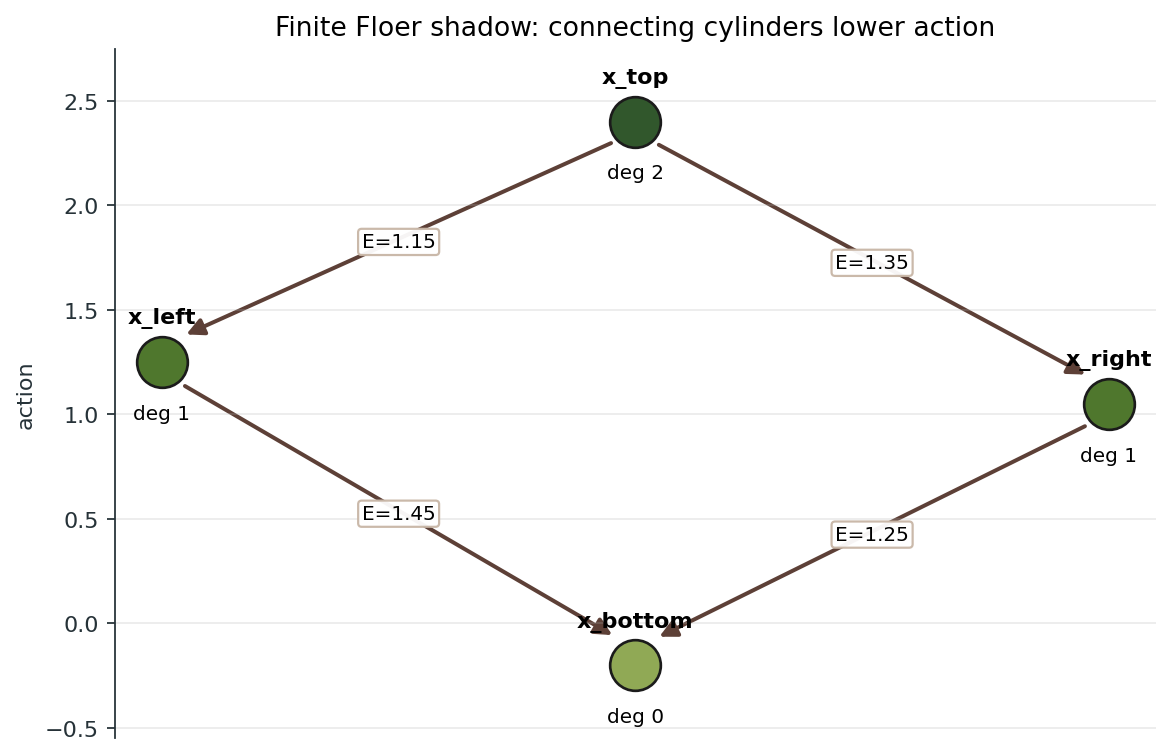

{'generators': [{'name': 'x_top',
   'degree': 2,
   'action': 2.4,
   'role': 'index-two orbit'},
  {'name': 'x_left', 'degree': 1, 'action': 1.25, 'role': 'index-one orbit'},
  {'name': 'x_right', 'degree': 1, 'action': 1.05, 'role': 'index-one orbit'},
  {'name': 'x_bottom',
   'degree': 0,
   'action': -0.2,
   'role': 'index-zero orbit'}],
 'edges': [{'source': 'x_top',
   'target': 'x_left',
   'count_mod2': 1,
   'energy': 1.15},
  {'source': 'x_top',
   'target': 'x_right',
   'count_mod2': 1,
   'energy': 1.3499999999999999},
  {'source': 'x_left', 'target': 'x_bottom', 'count_mod2': 1, 'energy': 1.45},
  {'source': 'x_right',
   'target': 'x_bottom',
   'count_mod2': 1,
   'energy': 1.25}],
 'd1_mod2': [[1, 1]],
 'd2_mod2': [[1], [1]],
 'd1_d2_mod2': [[0]],
 'd1_d2_signed': [[0]],
 'all_edges_lower_action': True,
 'min_energy': 1.15,
 'passed': True}

In [3]:
generators = pd.DataFrame([
    {"name": "x_top", "degree": 2, "action": 2.40, "x": 0.0, "y": 2.40, "role": "index-two orbit"},
    {"name": "x_left", "degree": 1, "action": 1.25, "x": -1.0, "y": 1.25, "role": "index-one orbit"},
    {"name": "x_right", "degree": 1, "action": 1.05, "x": 1.0, "y": 1.05, "role": "index-one orbit"},
    {"name": "x_bottom", "degree": 0, "action": -0.20, "x": 0.0, "y": -0.20, "role": "index-zero orbit"},
])
edges = pd.DataFrame([
    {"source": "x_top", "target": "x_left", "count_mod2": 1},
    {"source": "x_top", "target": "x_right", "count_mod2": 1},
    {"source": "x_left", "target": "x_bottom", "count_mod2": 1},
    {"source": "x_right", "target": "x_bottom", "count_mod2": 1},
])
act = dict(zip(generators["name"], generators["action"]))
edges["energy"] = edges.apply(lambda row: act[row["source"]] - act[row["target"]], axis=1)
d2 = np.array([[1], [1]], dtype=int)
d1 = np.array([[1, 1]], dtype=int)
d_squared_mod2 = (d1 @ d2) % 2
d2_signed = np.array([[1], [-1]], dtype=int)
d1_signed = np.array([[1, 1]], dtype=int)
d_squared_signed = d1_signed @ d2_signed

fig, ax = plt.subplots(figsize=(8.4, 5.6))
colors = {2: "#31572c", 1: "#4f772d", 0: "#90a955"}
for _, row in generators.iterrows():
    ax.scatter(row["x"], row["y"], s=520, color=colors[row["degree"]], edgecolor="#1b1b1b", linewidth=1.2, zorder=3)
    ax.text(row["x"], row["y"] + 0.16, row["name"], ha="center", va="bottom", weight="bold")
    ax.text(row["x"], row["y"] - 0.20, f"deg {row['degree']}", ha="center", va="top", fontsize=9)
pos = {row["name"]: (row["x"], row["y"]) for _, row in generators.iterrows()}
for _, row in edges.iterrows():
    x0, y0 = pos[row["source"]]
    x1, y1 = pos[row["target"]]
    arrow = FancyArrowPatch((x0, y0 - 0.05), (x1, y1 + 0.08), arrowstyle="-|>", mutation_scale=16, linewidth=1.8, color="#5d4037", shrinkA=12, shrinkB=12)
    ax.add_patch(arrow)
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    ax.text(xm, ym, f"E={row['energy']:.2f}", ha="center", va="center", bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "#c8b6a6", "alpha": 0.95}, fontsize=9)
ax.set_title("Finite Floer shadow: connecting cylinders lower action")
ax.set_ylabel("action")
ax.set_xticks([])
ax.set_ylim(-0.55, 2.75)
ax.grid(axis="y", alpha=0.25)
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)
fig_path = save_matplotlib(fig, UNIT, "figures", "floer-cochain-action-drop.png")
legacy_path = save_matplotlib(fig, UNIT, "figures", "floer-toy-action-complex.png")
plt.close(fig)

complex_csv = TABLE_DIR / "floer-generator-action-table.csv"
generators.to_csv(complex_csv, index=False)
edge_csv = TABLE_DIR / "floer-connecting-cylinder-table.csv"
edges.to_csv(edge_csv, index=False)
boundary_check = {
    "generators": generators[["name", "degree", "action", "role"]].to_dict(orient="records"),
    "edges": edges.to_dict(orient="records"),
    "d1_mod2": d1.tolist(),
    "d2_mod2": d2.tolist(),
    "d1_d2_mod2": d_squared_mod2.tolist(),
    "d1_d2_signed": d_squared_signed.tolist(),
    "all_edges_lower_action": bool((edges["energy"] > 0).all()),
    "min_energy": float(edges["energy"].min()),
    "passed": bool(np.all(d_squared_mod2 == 0) and np.all(d_squared_signed == 0) and (edges["energy"] > 0).all()),
}
boundary_path = save_json(boundary_check, UNIT, "checks", "floer-boundary-squared-checks.json")
display_artifact(fig_path, width=760)
display_artifact(complex_csv)
boundary_check


## 2. Finiteness, Compactness, and the Proof Skeleton for `d^2=0`

The analytic theorem behind the finite model says that, after regularity assumptions, the relevant one-dimensional moduli spaces compactify by adding broken trajectories. In a semipositive setting one must also keep sphere bubbling from adding extra boundary strata in the dimensions used for the differential and for `d^2=0`.

The dependency graph below is a proof-state map rather than a proof. The learner should read each arrow as a required implication: action control gives compactness input; compactness plus gluing identifies the boundary of a one-dimensional moduli space; that boundary is exactly what appears in the coefficient of `d^2`.


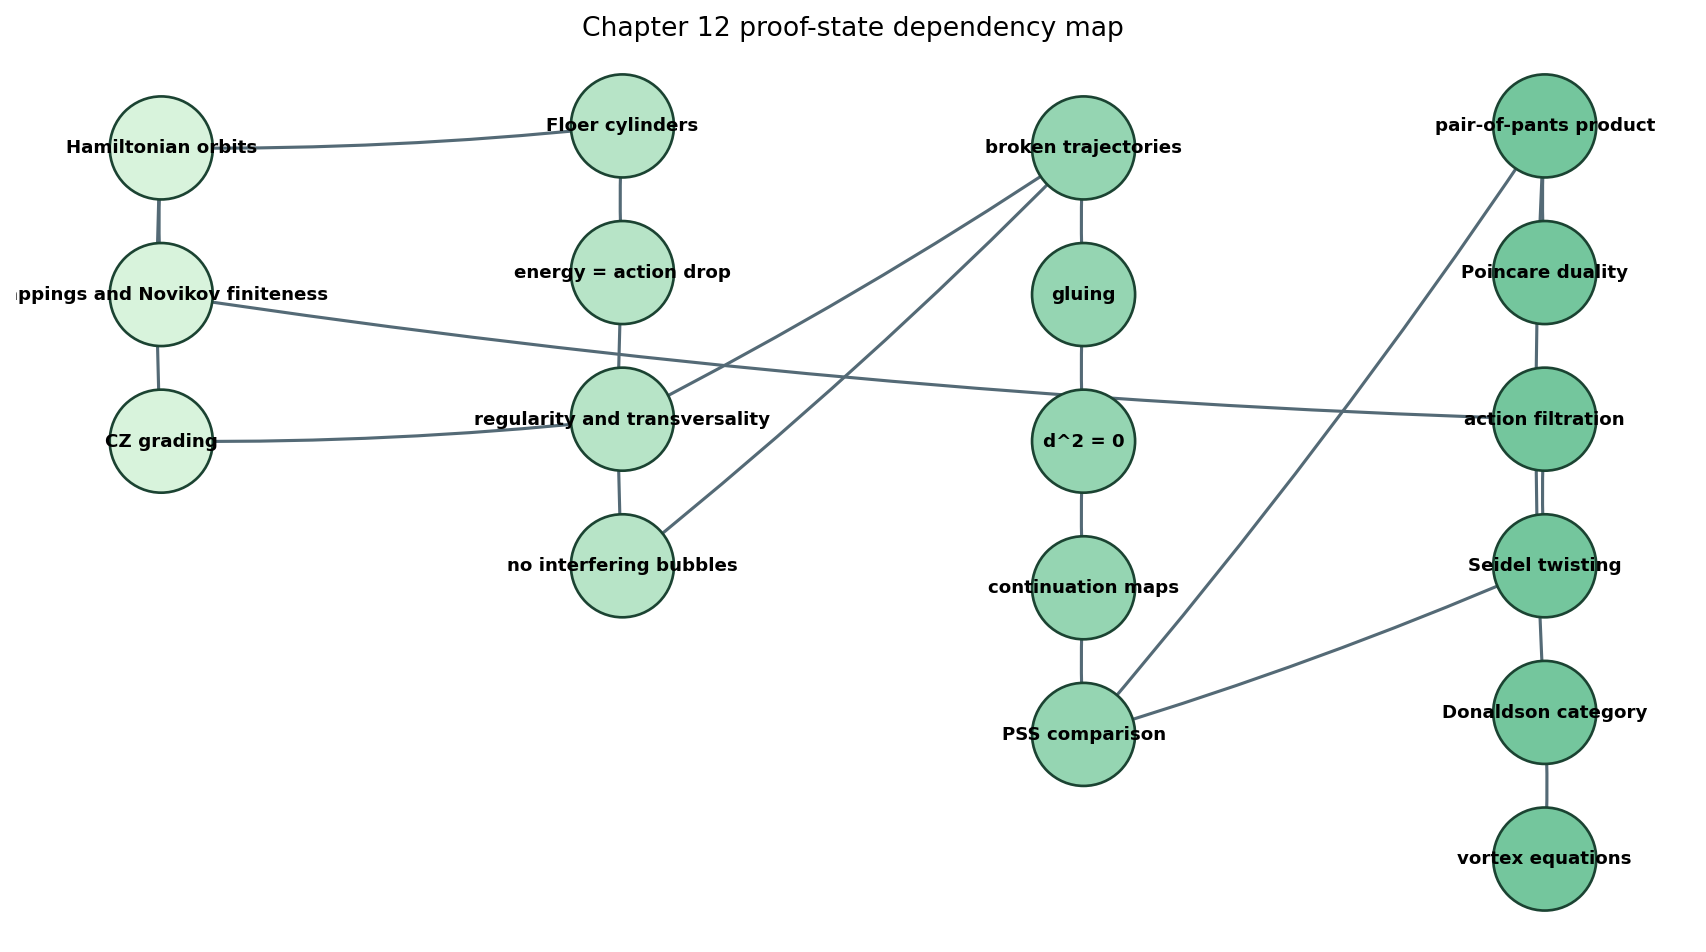

{'nodes': 18,
 'edges': 19,
 'is_directed_acyclic_graph': True,
 'sections_represented': ['12.1',
  '12.2',
  '12.3',
  '12.4',
  '12.5',
  '12.6',
  '12.7'],
 'topological_order_prefix': ['Hamiltonian orbits',
  'vortex equations',
  'cappings and Novikov finiteness',
  'CZ grading',
  'Floer cylinders',
  'action filtration'],
 'passed': True}

In [4]:
proof_nodes = {
    "Hamiltonian orbits": "12.1 generators",
    "cappings and Novikov finiteness": "12.1 finite sums",
    "CZ grading": "12.1 dimensions",
    "Floer cylinders": "12.1 connecting orbits",
    "energy = action drop": "12.1 compactness input",
    "regularity and transversality": "12.1 finite counts",
    "no interfering bubbles": "12.1 semipositivity use",
    "broken trajectories": "12.1 compactified boundary",
    "gluing": "12.1 d^2 proof",
    "d^2 = 0": "12.1 cohomology",
    "continuation maps": "12.1 invariance",
    "PSS comparison": "12.1 quantum comparison",
    "pair-of-pants product": "12.2 ring",
    "Poincare duality": "12.3 duality",
    "action filtration": "12.4 spectral invariants",
    "Seidel twisting": "12.5 loop action",
    "Donaldson category": "12.6 morphisms",
    "vortex equations": "12.7 gauged extension",
}
proof_edges = [
    ("Hamiltonian orbits", "cappings and Novikov finiteness"), ("Hamiltonian orbits", "CZ grading"), ("Hamiltonian orbits", "Floer cylinders"),
    ("cappings and Novikov finiteness", "action filtration"), ("CZ grading", "regularity and transversality"), ("Floer cylinders", "energy = action drop"),
    ("energy = action drop", "no interfering bubbles"), ("regularity and transversality", "broken trajectories"), ("no interfering bubbles", "broken trajectories"),
    ("broken trajectories", "gluing"), ("gluing", "d^2 = 0"), ("d^2 = 0", "continuation maps"), ("continuation maps", "PSS comparison"),
    ("PSS comparison", "pair-of-pants product"), ("pair-of-pants product", "Poincare duality"), ("pair-of-pants product", "Donaldson category"),
    ("action filtration", "Seidel twisting"), ("PSS comparison", "Seidel twisting"), ("vortex equations", "Donaldson category"),
]
PG = nx.DiGraph()
PG.add_nodes_from(proof_nodes)
PG.add_edges_from(proof_edges)
layers = {
    "input": ["Hamiltonian orbits", "cappings and Novikov finiteness", "CZ grading"],
    "analysis": ["Floer cylinders", "energy = action drop", "regularity and transversality", "no interfering bubbles"],
    "algebra": ["broken trajectories", "gluing", "d^2 = 0", "continuation maps", "PSS comparison"],
    "structures": ["pair-of-pants product", "Poincare duality", "action filtration", "Seidel twisting", "Donaldson category", "vortex equations"],
}
pos = {}
for col, names in enumerate(layers.values()):
    for row, name in enumerate(names):
        pos[name] = (col, -row + 0.15 * (col % 2))
fig, ax = plt.subplots(figsize=(13.5, 7.2))
nx.draw_networkx_edges(PG, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=13, width=1.4, edge_color="#546a76", connectionstyle="arc3,rad=0.03")
node_colors = []
for node in PG.nodes:
    if node in layers["input"]:
        node_colors.append("#d8f3dc")
    elif node in layers["analysis"]:
        node_colors.append("#b7e4c7")
    elif node in layers["algebra"]:
        node_colors.append("#95d5b2")
    else:
        node_colors.append("#74c69d")
nx.draw_networkx_nodes(PG, pos, ax=ax, node_size=2150, node_color=node_colors, edgecolors="#1b4332", linewidths=1.2)
nx.draw_networkx_labels(PG, pos, ax=ax, font_size=8.2, font_weight="bold")
ax.set_title("Chapter 12 proof-state dependency map")
ax.set_axis_off()
proof_fig = save_matplotlib(fig, UNIT, "figures", "floer-proof-dependency-map.png")
legacy_proof_fig = save_matplotlib(fig, UNIT, "figures", "proof-dependency-map.png")
plt.close(fig)
proof_check = {
    "nodes": len(PG.nodes),
    "edges": len(PG.edges),
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(PG),
    "sections_represented": sorted({label.split()[0] for label in proof_nodes.values()}),
    "topological_order_prefix": list(nx.topological_sort(PG))[:6],
    "passed": bool(nx.is_directed_acyclic_graph(PG) and len(PG.nodes) >= 16 and "12.7" in {label.split()[0] for label in proof_nodes.values()}),
}
proof_json = save_json(proof_check, UNIT, "checks", "proof-dependency-map.json")
display_artifact(proof_fig, width=980)
proof_check


## 3. Action Filtration and Spectral Values

The action filtration keeps only chains whose generators lie below a cutoff. A spectral invariant asks for the first action level at which a chosen homology class can be represented. In the full theory, the value is independent of auxiliary choices and lies in the action spectrum. In the finite model, we can compute it by scanning thresholds.

The barcode below uses two persistent classes from the circle shadow: a lower class born at `x_min` and an upper class born at `x_max`. The vertical marker identifies the spectral value for the class named `top_class`.


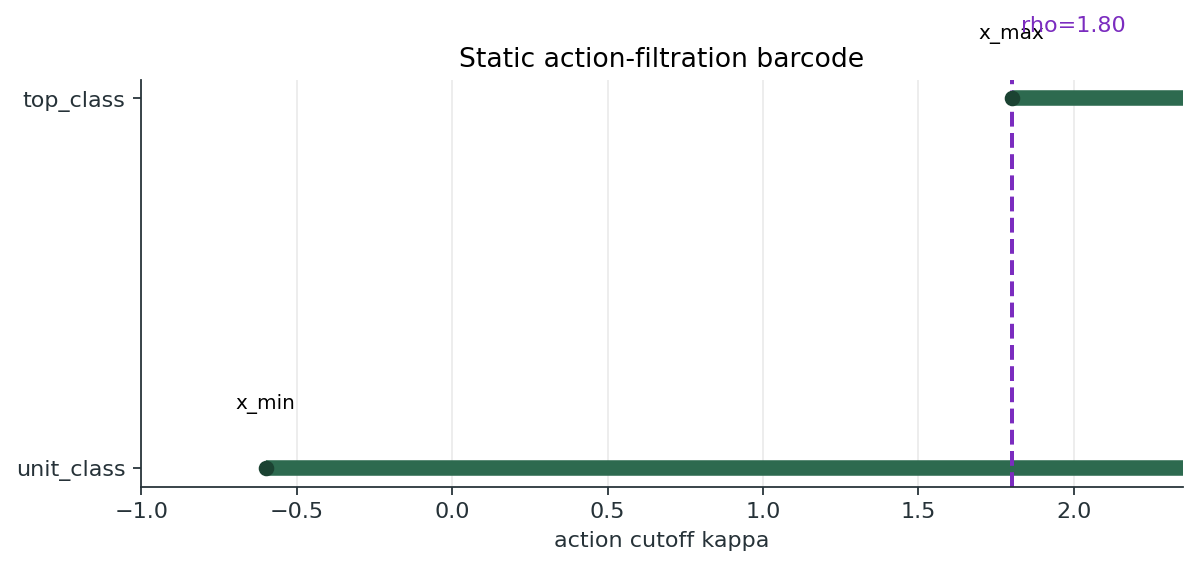

{'action_spectrum': [-0.6, -0.2, 1.05, 1.25, 1.8, 2.4],
 'spectral_values': {'unit_class': -0.6, 'top_class': 1.8},
 'visibility_scan': [{'kappa': -1.0, 'visible_classes': []},
  {'kappa': -0.8, 'visible_classes': []},
  {'kappa': -0.6, 'visible_classes': ['unit_class']},
  {'kappa': -0.3999999999999999, 'visible_classes': ['unit_class']},
  {'kappa': -0.19999999999999996, 'visible_classes': ['unit_class']},
  {'kappa': 0.0, 'visible_classes': ['unit_class']},
  {'kappa': 0.20000000000000018, 'visible_classes': ['unit_class']},
  {'kappa': 0.40000000000000013, 'visible_classes': ['unit_class']},
  {'kappa': 0.6000000000000001, 'visible_classes': ['unit_class']},
  {'kappa': 0.8, 'visible_classes': ['unit_class']},
  {'kappa': 1.0, 'visible_classes': ['unit_class']},
  {'kappa': 1.2000000000000002, 'visible_classes': ['unit_class']},
  {'kappa': 1.4000000000000004, 'visible_classes': ['unit_class']},
  {'kappa': 1.6, 'visible_classes': ['unit_class']},
  {'kappa': 1.8000000000000003,
  

In [5]:
filtration_classes = pd.DataFrame([
    {"class": "unit_class", "degree": 0, "birth_action": -0.60, "representative": "x_min"},
    {"class": "top_class", "degree": 1, "birth_action": 1.80, "representative": "x_max"},
])
action_spectrum = sorted(filtration_classes["birth_action"].tolist() + generators["action"].round(6).tolist())
kappa_grid = np.linspace(-1.0, 2.2, 17)
visibility = []
for kappa in kappa_grid:
    visibility.append({"kappa": float(kappa), "visible_classes": filtration_classes.loc[filtration_classes["birth_action"] <= kappa, "class"].tolist()})
spectral_values = {row["class"]: float(row["birth_action"]) for _, row in filtration_classes.iterrows()}
selected_class = "top_class"
selected_rho = spectral_values[selected_class]

fig = go.Figure()
for _, row in filtration_classes.iterrows():
    fig.add_trace(go.Scatter(x=[row["birth_action"], 2.35], y=[row["class"], row["class"]], mode="lines+markers", line={"width": 8}, marker={"size": 10}, name=f"{row['class']} born at {row['birth_action']:.2f}", hovertemplate="class=%{y}<br>action=%{x:.2f}<extra></extra>"))
fig.add_vline(x=selected_rho, line_dash="dash", line_color="#7b2cbf", annotation_text=f"rho({selected_class})={selected_rho:.2f}", annotation_position="top")
fig.update_layout(title="Filtered Floer barcode: classes appear at action thresholds", xaxis_title="action cutoff kappa", yaxis_title="homology class", height=360, template="plotly_white", showlegend=True)
barcode_html = HTML_DIR / "action-filtration-barcode.html"
fig.write_html(barcode_html, include_plotlyjs=True, full_html=True)

fig2, ax = plt.subplots(figsize=(8.4, 3.3))
for i, row in filtration_classes.iterrows():
    ax.hlines(i, row["birth_action"], 2.35, color="#2d6a4f", linewidth=7)
    ax.scatter([row["birth_action"]], [i], color="#1b4332", zorder=3)
    ax.text(row["birth_action"], i + 0.16, row["representative"], ha="center", fontsize=9)
ax.axvline(selected_rho, color="#7b2cbf", linestyle="--", linewidth=1.8)
ax.text(selected_rho + 0.03, 1.18, f"rho={selected_rho:.2f}", color="#7b2cbf")
ax.set_yticks(range(len(filtration_classes)))
ax.set_yticklabels(filtration_classes["class"])
ax.set_xlabel("action cutoff kappa")
ax.set_title("Static action-filtration barcode")
ax.set_xlim(-1.0, 2.35)
ax.grid(axis="x", alpha=0.25)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
barcode_png = save_matplotlib(fig2, UNIT, "figures", "action-filtration-barcode.png")
plt.close(fig2)
barcode_check = {
    "action_spectrum": [float(x) for x in action_spectrum],
    "spectral_values": spectral_values,
    "visibility_scan": visibility,
    "selected_class": selected_class,
    "selected_rho": selected_rho,
    "selected_value_in_spectrum": bool(any(abs(selected_rho - s) < 1e-9 for s in action_spectrum)),
    "births_sorted": bool(all(np.diff(sorted(spectral_values.values())) >= 0)),
    "passed": bool(any(abs(selected_rho - s) < 1e-9 for s in action_spectrum)),
}
barcode_json = save_json(barcode_check, UNIT, "checks", "action-filtration-spectral-checks.json")
display_artifact(barcode_html, width="100%", height=430)
display_artifact(barcode_png, width=760)
barcode_check


## 4. Continuation, PSS, and Pair-of-Pants Multiplication

Continuation says that changing a regular Hamiltonian/almost-complex pair does not change Floer cohomology, only the chain model used to compute it. The PSS comparison then identifies Floer cohomology with quantum cohomology. Section 12.2 adds a product: a three-ended surface counts pair-of-pants solutions, and the PSS map turns that product into the quantum product.

The executable algebra below uses the standard two-dimensional toy ring for `QH(CP1)`: basis `1, H` and relation `H*H=q`. The point is not the example itself; it is the checks: unit, associativity, continuation naturality, and product compatibility.


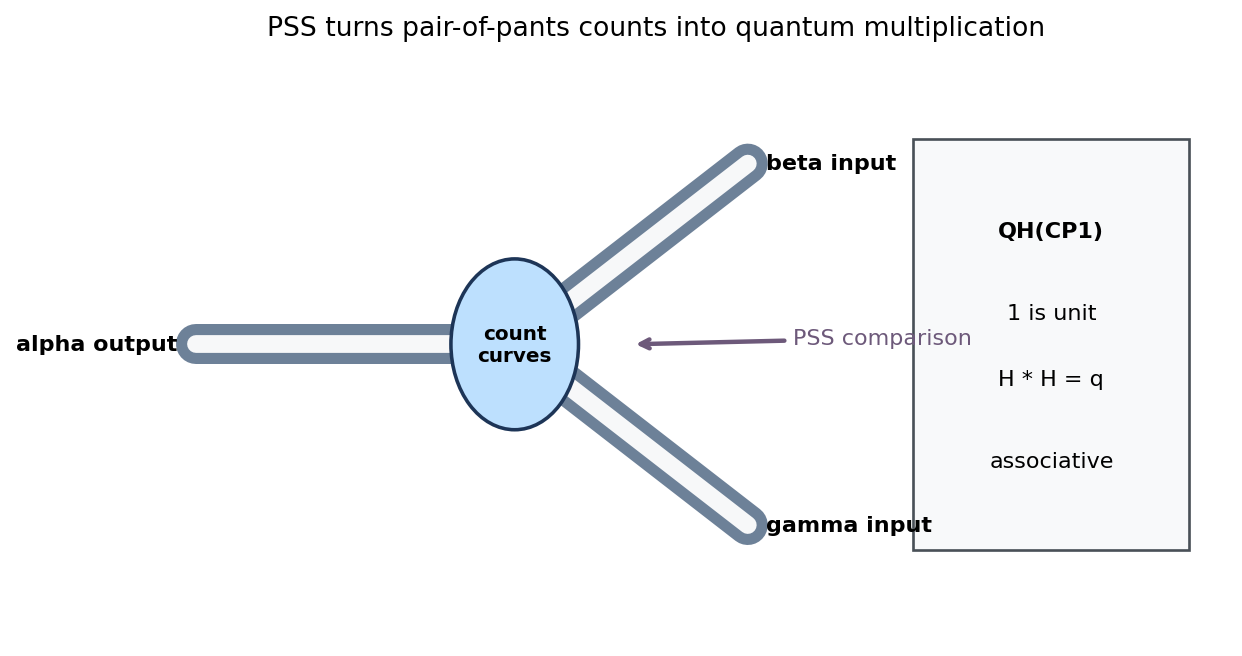

{'quantum_product_table': [{'left_input': '1',
   'right_input': '1',
   'product': '1*1',
   'coeff_1': '1',
   'coeff_H': '0',
   'geometric_reading': 'classical unit action',
   'floer_shadow': 'pair-of-pants count transported through PSS'},
  {'left_input': '1',
   'right_input': 'H',
   'product': '1*H',
   'coeff_1': '0',
   'coeff_H': '1',
   'geometric_reading': 'classical unit action',
   'floer_shadow': 'pair-of-pants count transported through PSS'},
  {'left_input': 'H',
   'right_input': '1',
   'product': 'H*1',
   'coeff_1': '0',
   'coeff_H': '1',
   'geometric_reading': 'classical unit action',
   'floer_shadow': 'pair-of-pants count transported through PSS'},
  {'left_input': 'H',
   'right_input': 'H',
   'product': 'H*H',
   'coeff_1': 'q',
   'coeff_H': '0',
   'geometric_reading': 'two hyperplane constraints contribute the q-correction',
   'floer_shadow': 'pair-of-pants count transported through PSS'}],
 'associativity_residual': ['0', '0'],
 'unit_residual': ['0'

In [6]:
q = sp.symbols("q")


def qh_mul(u, v):
    a, b = u
    c, d = v
    return (sp.expand(a*c + b*d*q), sp.expand(a*d + b*c))


basis = {"1": (sp.Integer(1), sp.Integer(0)), "H": (sp.Integer(0), sp.Integer(1))}
products = {}
for left_name, left in basis.items():
    for right_name, right in basis.items():
        prod = qh_mul(left, right)
        products[f"{left_name}*{right_name}"] = [str(prod[0]), str(prod[1])]
a0, a1, b0, b1, c0, c1 = sp.symbols("a0 a1 b0 b1 c0 c1")
a = (a0, a1); b = (b0, b1); c = (c0, c1)
assoc_left = qh_mul(qh_mul(a, b), c)
assoc_right = qh_mul(a, qh_mul(b, c))
associativity_residual = [sp.simplify(L - R) for L, R in zip(assoc_left, assoc_right)]
unit_residual = [sp.simplify(x - y) for x, y in zip(qh_mul(basis["1"], a), a)] + [sp.simplify(x - y) for x, y in zip(qh_mul(a, basis["1"]), a)]
continuation_beta_to_alpha = sp.Matrix([[1, 0], [0, 1]])
pss_alpha = sp.Matrix([[1, 0], [0, 1]])
pss_beta = sp.Matrix([[1, 0], [0, 1]])
naturality_residual = pss_alpha * continuation_beta_to_alpha - pss_beta
x = basis["H"]; y = basis["H"]
pp_product_floer_shadow = qh_mul(x, y)
pss_product_target = qh_mul(x, y)
product_compatibility = pp_product_floer_shadow == pss_product_target

product_rows = []
for name, value in products.items():
    left, right = name.split("*")
    product_rows.append({
        "left_input": left,
        "right_input": right,
        "product": name,
        "coeff_1": value[0],
        "coeff_H": value[1],
        "geometric_reading": "classical unit action" if "1" in (left, right) else "two hyperplane constraints contribute the q-correction",
        "floer_shadow": "pair-of-pants count transported through PSS",
    })
product_table = TABLE_DIR / "quantum-pair-of-pants-product-table.csv"
pd.DataFrame(product_rows).to_csv(product_table, index=False)

fig, ax = plt.subplots(figsize=(9.2, 4.8))
ax.set_axis_off()
center = np.array([0.0, 0.0])
ends = {"alpha output": np.array([-2.6, 0.0]), "beta input": np.array([1.9, 1.1]), "gamma input": np.array([1.9, -1.1])}
for label, end in ends.items():
    ax.plot([center[0], end[0]], [center[1], end[1]], color="#355070", linewidth=18, solid_capstyle="round", alpha=0.72)
    ax.plot([center[0], end[0]], [center[1], end[1]], color="white", linewidth=8, solid_capstyle="round", alpha=0.95)
    ax.text(end[0] + (0.15 if end[0] > 0 else -0.15), end[1], label, ha="left" if end[0] > 0 else "right", va="center", weight="bold")
ax.add_patch(Circle(center, 0.52, facecolor="#bde0fe", edgecolor="#1d3557", linewidth=1.6, zorder=3))
ax.text(0, 0, "count\ncurves", ha="center", va="center", fontsize=9, weight="bold", zorder=4)
ax.annotate("PSS comparison", xy=(0.95, 0.0), xytext=(3.0, 0.0), arrowprops={"arrowstyle": "->", "lw": 2, "color": "#6d597a"}, color="#6d597a", ha="center")
ax.add_patch(Rectangle((3.25, -1.25), 2.25, 2.5, facecolor="#f8f9fa", edgecolor="#495057", linewidth=1.2))
ax.text(4.375, 0.65, "QH(CP1)", ha="center", weight="bold")
ax.text(4.375, 0.15, "1 is unit", ha="center")
ax.text(4.375, -0.25, "H * H = q", ha="center")
ax.text(4.375, -0.75, "associative", ha="center")
ax.set_xlim(-3.5, 5.8); ax.set_ylim(-1.8, 1.8)
ax.set_title("PSS turns pair-of-pants counts into quantum multiplication")
pss_fig = save_matplotlib(fig, UNIT, "figures", "pss-pair-of-pants-comparison.png")
plt.close(fig)
pss_check = {
    "quantum_product_table": product_rows,
    "associativity_residual": [str(r) for r in associativity_residual],
    "unit_residual": [str(r) for r in unit_residual],
    "continuation_naturality_residual": [[str(x) for x in row] for row in naturality_residual.tolist()],
    "product_compatibility_sample_H_times_H": bool(product_compatibility),
    "passed": bool(all(r == 0 for r in associativity_residual) and all(r == 0 for r in unit_residual) and naturality_residual == sp.zeros(2, 2) and product_compatibility),
}
pss_json = save_json(pss_check, UNIT, "checks", "pss-product-comparison-checks.json")
display_artifact(pss_fig, width=780)
display_artifact(product_table)
pss_check


## 5. Poincare Duality in the Floer Language

Floer cohomology and homology use opposite finiteness directions for the action. Reversing the Hamiltonian reverses action and degree, and the Floer pairing becomes the bridge to Poincare duality after applying PSS. In a small finite model this is the anti-diagonal pairing for `CP1`: `1` pairs with `H`, and `H` pairs with `1`.

The check below keeps two pieces visible: the action/degree reversal and the nondegenerate pairing matrix.


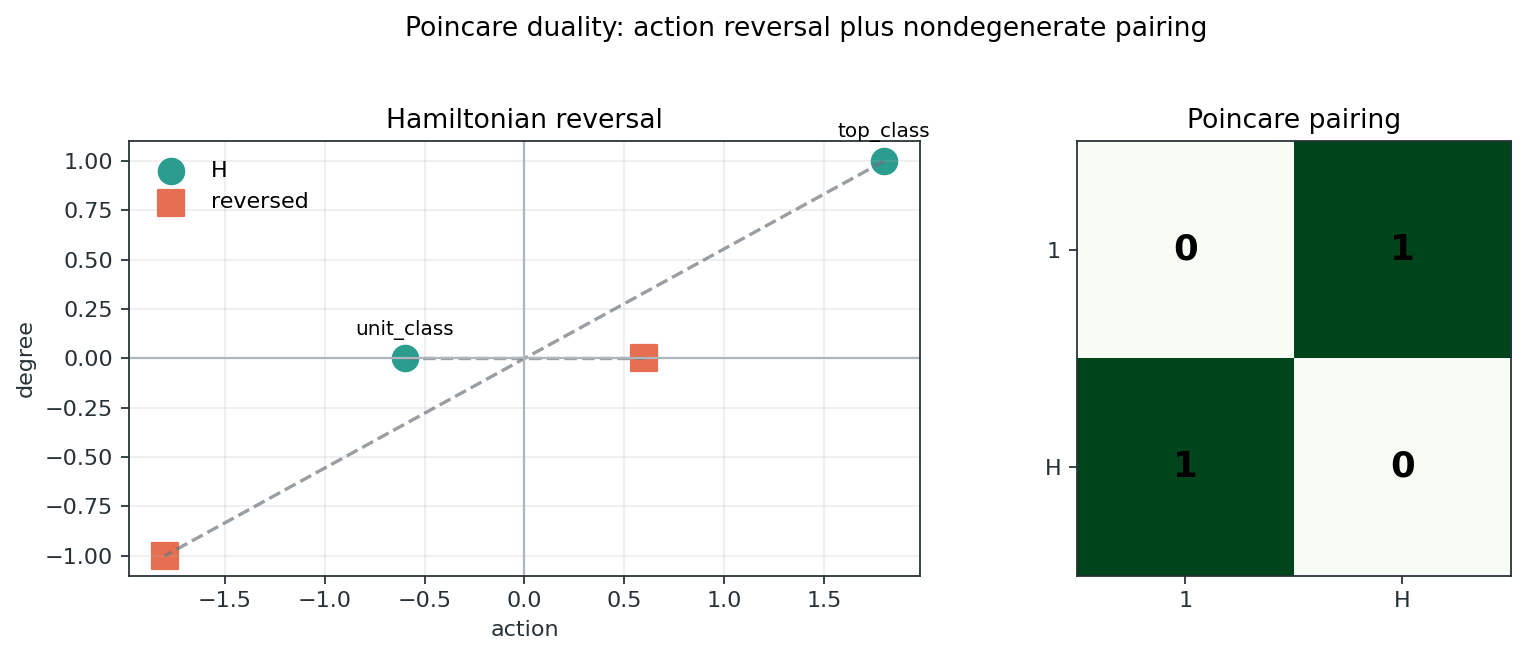

{'basis': ['1', 'H'],
 'pairing_matrix': [[0, 1], [1, 0]],
 'pairing_determinant': -1,
 'action_reversal_rows': [{'class': 'unit_class',
   'degree': 0,
   'action_H': -0.6,
   'degree_reversed': 0,
   'action_reversed_H_hat': 0.6},
  {'class': 'top_class',
   'degree': 1,
   'action_H': 1.8,
   'degree_reversed': -1,
   'action_reversed_H_hat': -1.8}],
 'top_coeff_pairing_ok': True,
 'passed': True}

In [7]:
duality_rows = []
for _, row in filtration_classes.iterrows():
    duality_rows.append({"class": row["class"], "degree": int(row["degree"]), "action_H": float(row["birth_action"]), "degree_reversed": int(-row["degree"]), "action_reversed_H_hat": float(-row["birth_action"])})
duality_df = pd.DataFrame(duality_rows)
duality_csv = TABLE_DIR / "poincare-duality-action-reversal.csv"
duality_df.to_csv(duality_csv, index=False)
pairing = np.array([[0, 1], [1, 0]], dtype=int)
pairing_det = int(round(np.linalg.det(pairing)))


def classical_mul(u, v):
    a, b = u
    c, d = v
    return (sp.expand(a*c), sp.expand(a*d + b*c))


top_coeff_pairing_ok = True
for left_name, left in basis.items():
    for right_name, right in basis.items():
        coeff_H = classical_mul(left, right)[1]
        expected = pairing[["1", "H"].index(left_name), ["1", "H"].index(right_name)]
        top_coeff_pairing_ok = top_coeff_pairing_ok and (sp.simplify(coeff_H - expected) == 0)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.0), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
for _, row in duality_df.iterrows():
    ax.scatter(row["action_H"], row["degree"], s=130, color="#2a9d8f", label="H" if row.name == 0 else None)
    ax.scatter(row["action_reversed_H_hat"], row["degree_reversed"], s=130, color="#e76f51", marker="s", label="reversed" if row.name == 0 else None)
    ax.plot([row["action_H"], row["action_reversed_H_hat"]], [row["degree"], row["degree_reversed"]], color="#6c757d", linestyle="--", alpha=0.7)
    ax.text(row["action_H"], row["degree"] + 0.12, row["class"], ha="center", fontsize=9)
ax.axvline(0, color="#adb5bd", linewidth=1)
ax.axhline(0, color="#adb5bd", linewidth=1)
ax.set_xlabel("action"); ax.set_ylabel("degree"); ax.set_title("Hamiltonian reversal")
ax.legend(frameon=False); ax.grid(alpha=0.22)
ax = axes[1]
ax.imshow(pairing, cmap="Greens", vmin=0, vmax=1)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["1", "H"]); ax.set_yticklabels(["1", "H"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(pairing[i, j]), ha="center", va="center", fontsize=16, weight="bold")
ax.set_title("Poincare pairing")
fig.suptitle("Poincare duality: action reversal plus nondegenerate pairing", y=1.02)
fig.tight_layout()
pd_fig = save_matplotlib(fig, UNIT, "figures", "poincare-duality-action-reversal.png")
plt.close(fig)
pd_check = {
    "basis": ["1", "H"],
    "pairing_matrix": pairing.tolist(),
    "pairing_determinant": pairing_det,
    "action_reversal_rows": duality_rows,
    "top_coeff_pairing_ok": bool(top_coeff_pairing_ok),
    "passed": bool(pairing_det != 0 and top_coeff_pairing_ok and all(abs(r["action_H"] + r["action_reversed_H_hat"]) < 1e-12 for r in duality_rows)),
}
pd_json = save_json(pd_check, UNIT, "checks", "poincare-duality-checks.json")
display_artifact(pd_fig, width=820)
pd_check


## 6. Seidel Representation and Spectral Shift

A Hamiltonian loop acts on the Floer equation by pulling back the solution. To make that action unambiguous on capped orbits, one also chooses a section class in the associated Hamiltonian fibration. Under PSS, this operation is quantum multiplication by the Seidel element. The action level shifts by the section's coupling-area term.

The toy model chooses the Seidel element `H` in `QH(CP1)`. Since `H*H=q`, multiplication by `H` is invertible once the Novikov variable is allowed. The spectral shift check is a finite version of the monodromy-shift formula.


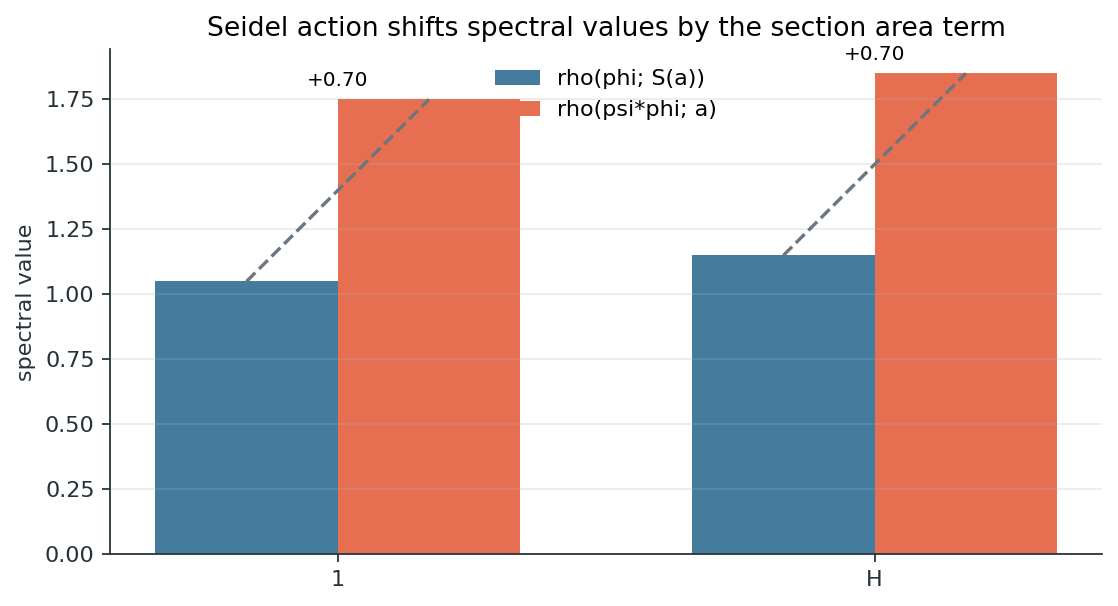

{'seidel_element': 'H',
 'multiplication_matrix_basis_1_H': [['0', 'q'], ['1', '0']],
 'determinant': '-q',
 'inverse_residual': [['0', '0'], ['0', '0']],
 'omega_tau': 0.7,
 'rho_phi': {'1': 0.15, 'H': 1.05, 'q*1': 1.15},
 'rho_psi_star_phi': {'1': 1.75, 'H': 1.8499999999999999},
 'shift_residuals': {'1': 0.0, 'H': 0.0},
 'passed': True}

In [8]:
seidel_matrix = sp.Matrix([[0, q], [1, 0]])
seidel_det = sp.factor(seidel_matrix.det())
inverse_candidate = sp.Matrix([[0, 1], [1/q, 0]])
inverse_residual = sp.simplify(seidel_matrix * inverse_candidate - sp.eye(2))
omega_tau = 0.70
rho_phi = {"1": 0.15, "H": 1.05, "q*1": 1.15}
seidel_action_on_classes = {"1": "H", "H": "q*1"}
rho_psi_star_phi = {cls: rho_phi[seidel_action_on_classes[cls]] + omega_tau for cls in ["1", "H"]}
shift_residuals = {cls: rho_psi_star_phi[cls] - rho_phi[seidel_action_on_classes[cls]] - omega_tau for cls in ["1", "H"]}

fig, ax = plt.subplots(figsize=(8.0, 4.1))
labels = ["1", "H"]; xvals = np.arange(len(labels))
base_vals = [rho_phi[seidel_action_on_classes[label]] for label in labels]
shifted_vals = [rho_psi_star_phi[label] for label in labels]
ax.bar(xvals - 0.17, base_vals, width=0.34, color="#457b9d", label="rho(phi; S(a))")
ax.bar(xvals + 0.17, shifted_vals, width=0.34, color="#e76f51", label="rho(psi*phi; a)")
for i, label in enumerate(labels):
    ax.plot([i - 0.17, i + 0.17], [base_vals[i], shifted_vals[i]], color="#6c757d", linestyle="--")
    ax.text(i, shifted_vals[i] + 0.05, f"+{omega_tau:.2f}", ha="center", fontsize=9)
ax.set_xticks(xvals); ax.set_xticklabels(labels)
ax.set_ylabel("spectral value")
ax.set_title("Seidel action shifts spectral values by the section area term")
ax.legend(frameon=False); ax.grid(axis="y", alpha=0.25)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
seidel_fig = save_matplotlib(fig, UNIT, "figures", "seidel-spectral-shift.png")
plt.close(fig)
seidel_check = {
    "seidel_element": "H",
    "multiplication_matrix_basis_1_H": [[str(x) for x in row] for row in seidel_matrix.tolist()],
    "determinant": str(seidel_det),
    "inverse_residual": [[str(x) for x in row] for row in inverse_residual.tolist()],
    "omega_tau": omega_tau,
    "rho_phi": rho_phi,
    "rho_psi_star_phi": rho_psi_star_phi,
    "shift_residuals": shift_residuals,
    "passed": bool(seidel_det != 0 and inverse_residual == sp.zeros(2, 2) and all(abs(v) < 1e-12 for v in shift_residuals.values())),
}
seidel_json = save_json(seidel_check, UNIT, "checks", "seidel-representation-checks.json")
display_artifact(seidel_fig, width=760)
seidel_check


## 7. Donaldson's Quantum Category

Donaldson's viewpoint turns Floer groups into morphism spaces. For symplectomorphisms, a morphism from `phi` to `psi` is modeled by a Floer group of `psi phi^{-1}`; composition is a product counted over a three-ended surface. The same categorical idea also appears for Lagrangians, where morphisms are Lagrangian Floer groups and composition counts holomorphic triangles.

The graph below is deliberately finite: it checks the categorical bookkeeping, not the analytic construction. The important rule is that labels compose in the right order and associativity is inherited from the product/gluing picture.


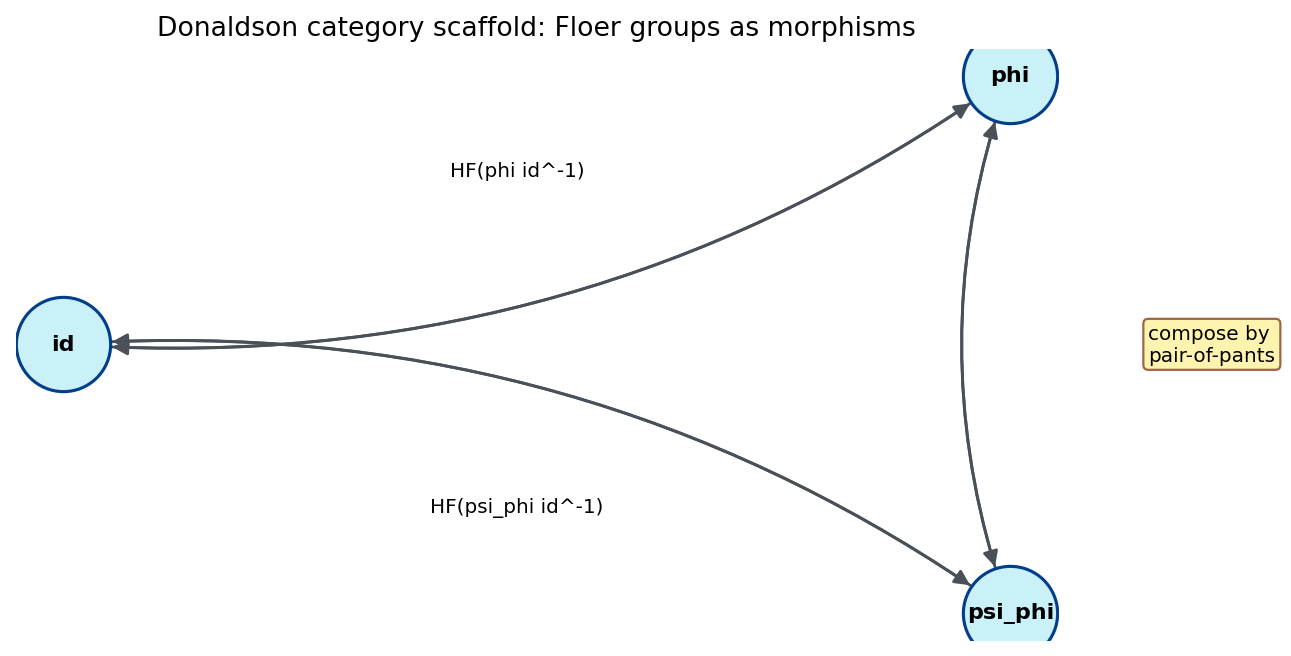

{'objects': ['id', 'phi', 'psi_phi'],
 'morphism_count': 9,
 'associativity_witnesses': [{'path': ['id', 'phi', 'psi_phi', 'id'],
   'left': 0,
   'right': 0}],
 'identity_labels_zero': True,
 'passed': True}

In [9]:
objects = ["id", "phi", "psi_phi"]
object_group_value = {"id": 0, "phi": 1, "psi_phi": 2}
morphisms = []
for source in objects:
    for target in objects:
        label_value = object_group_value[target] - object_group_value[source]
        morphisms.append({"source": source, "target": target, "label": f"HF({target} {source}^-1)", "value": label_value})


def compose_values(f, g):
    return f + g


assoc_category_ok = True
assoc_witnesses = []
for a_obj in objects:
    for b_obj in objects:
        for c_obj in objects:
            for d_obj in objects:
                f = object_group_value[b_obj] - object_group_value[a_obj]
                g = object_group_value[c_obj] - object_group_value[b_obj]
                h = object_group_value[d_obj] - object_group_value[c_obj]
                left = compose_values(compose_values(f, g), h)
                right = compose_values(f, compose_values(g, h))
                assoc_category_ok = assoc_category_ok and (left == right)
                if a_obj == "id" and b_obj == "phi" and c_obj == "psi_phi" and d_obj == "id":
                    assoc_witnesses.append({"path": [a_obj, b_obj, c_obj, d_obj], "left": left, "right": right})

CG = nx.MultiDiGraph()
for obj in objects:
    CG.add_node(obj)
for row in morphisms:
    if row["source"] != row["target"]:
        CG.add_edge(row["source"], row["target"], label=row["label"])
pos_cat = {"id": (0, 0), "phi": (2.4, 1.15), "psi_phi": (2.4, -1.15)}
fig, ax = plt.subplots(figsize=(8.4, 4.8))
nx.draw_networkx_nodes(CG, pos_cat, ax=ax, node_size=1800, node_color="#caf0f8", edgecolors="#023e8a", linewidths=1.4)
nx.draw_networkx_labels(CG, pos_cat, ax=ax, font_size=10, font_weight="bold")
for (u, v, key, data) in CG.edges(keys=True, data=True):
    rad = 0.18 if (u, v) in [("id", "phi"), ("phi", "psi_phi"), ("psi_phi", "id")] else -0.18
    arrow = FancyArrowPatch(pos_cat[u], pos_cat[v], arrowstyle="-|>", mutation_scale=14, linewidth=1.3, color="#495057", connectionstyle=f"arc3,rad={rad}", shrinkA=22, shrinkB=22)
    ax.add_patch(arrow)
ax.text(1.15, 0.72, "HF(phi id^-1)", ha="center", fontsize=9)
ax.text(2.75, 0.00, "compose by\npair-of-pants", ha="left", va="center", fontsize=9, bbox={"boxstyle": "round,pad=0.25", "fc": "#fff3b0", "ec": "#9c6644"})
ax.text(1.15, -0.72, "HF(psi_phi id^-1)", ha="center", fontsize=9)
ax.set_title("Donaldson category scaffold: Floer groups as morphisms")
ax.set_axis_off()
category_fig = save_matplotlib(fig, UNIT, "figures", "donaldson-quantum-category-scaffold.png")
plt.close(fig)
category_table = TABLE_DIR / "donaldson-category-morphism-table.csv"
pd.DataFrame(morphisms).to_csv(category_table, index=False)
category_check = {
    "objects": objects,
    "morphism_count": len(morphisms),
    "associativity_witnesses": assoc_witnesses,
    "identity_labels_zero": all((object_group_value[obj] - object_group_value[obj]) == 0 for obj in objects),
    "passed": bool(assoc_category_ok and len(morphisms) == len(objects) ** 2),
}
category_json = save_json(category_check, UNIT, "checks", "donaldson-category-checks.json")
display_artifact(category_fig, width=760)
display_artifact(category_table)
category_check


## 8. Symplectic Vortices and the Moment/Floer Connection

The vortex equations add gauge fields to the holomorphic-curve story. A connection contributes curvature, a moment map contributes a constraint, and solutions minimize an energy whose topological part is equivariant. In a local trivialization the equations resemble a Floer equation coupled to a curvature-moment equation.

For the standard `S1` action on `C`, take `mu(z) = |z|^2/2 - tau`. The quotient level `mu=0` is a circle before dividing by `S1`. The adiabatic equation contains a penalty proportional to `epsilon^{-2} mu`, so as `epsilon` shrinks the model strongly favors points close to `mu=0`. This is the visual bridge to the quantum Kirwan and moment-Floer discussion at the end of the chapter.


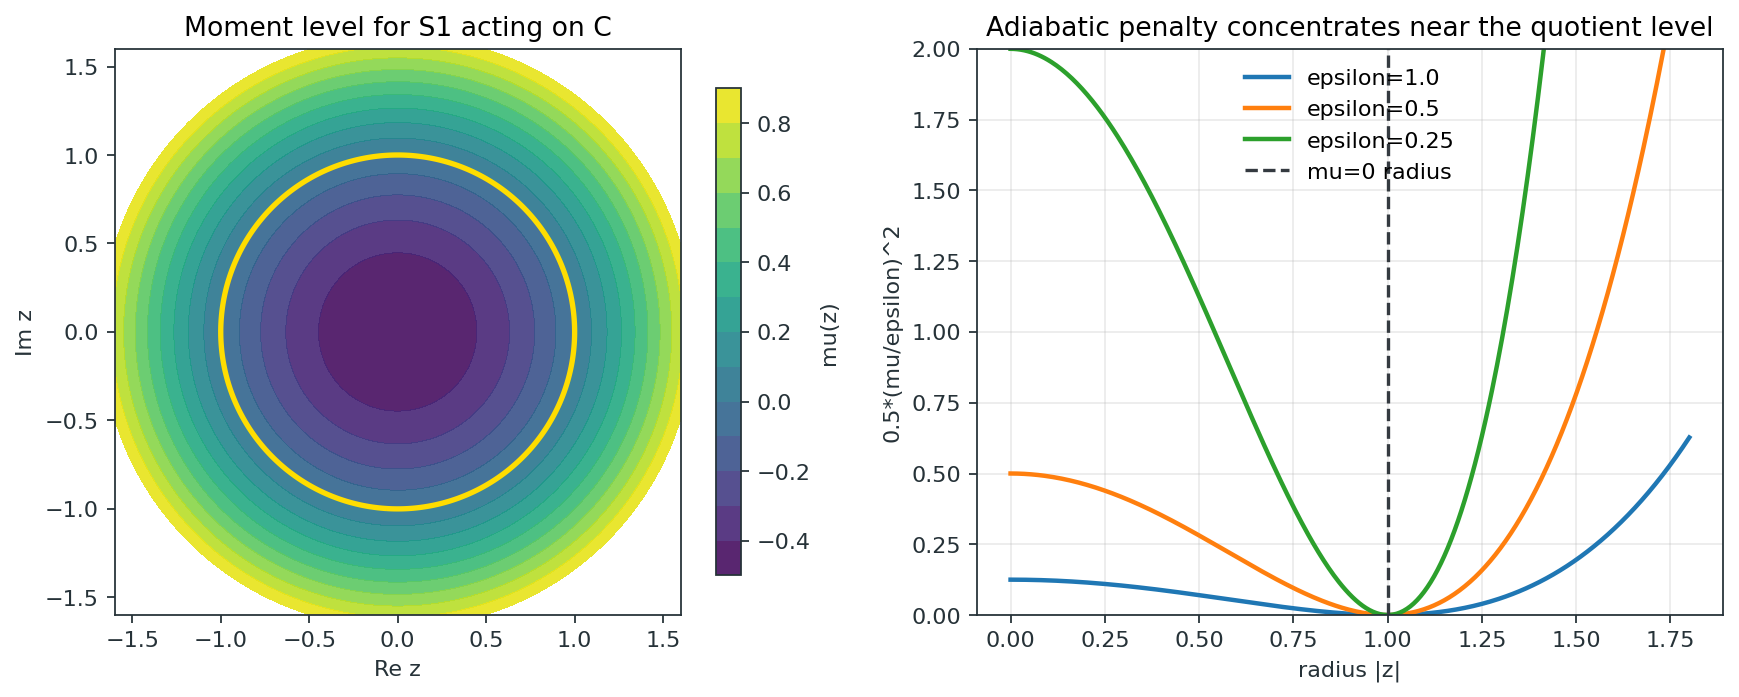

{'tau': 0.5,
 'expected_mu_zero_radius': 1.0,
 'min_radii_by_epsilon': {1.0: 1.0015037593984963,
  0.5: 1.0015037593984963,
  0.25: 1.0015037593984963},
 'max_radius_error': 0.0015037593984963404,
 'critical_loop_moment_residual': 0.0,
 'moment_floer_functional_shadow': -0.0,
 'interpretation': 'Finite S1-on-C scaffold for the curvature/moment equation and moment-Floer action term.',
 'passed': True}

In [10]:
tau = 0.5
xs = np.linspace(-1.6, 1.6, 240)
ys = np.linspace(-1.6, 1.6, 240)
X, Y = np.meshgrid(xs, ys)
R2 = X**2 + Y**2
MU = 0.5 * R2 - tau
expected_radius = math.sqrt(2 * tau)
r = np.linspace(0, 1.8, 400)
mu_r = 0.5 * r**2 - tau
epsilons = [1.0, 0.5, 0.25]
penalties = {eps: 0.5 * (mu_r / eps)**2 for eps in epsilons}
min_radii = {eps: float(r[np.argmin(vals)]) for eps, vals in penalties.items()}

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.5), gridspec_kw={"width_ratios": [1, 1.05]})
ax = axes[0]
levels = np.linspace(-tau, 0.9, 15)
cont = ax.contourf(X, Y, MU, levels=levels, cmap="viridis", alpha=0.9)
ax.contour(X, Y, MU, levels=[0], colors="#ffdd00", linewidths=2.4)
ax.add_patch(Circle((0, 0), expected_radius, fill=False, edgecolor="white", linewidth=1.2, linestyle="--"))
ax.set_aspect("equal")
ax.set_title("Moment level for S1 acting on C")
ax.set_xlabel("Re z"); ax.set_ylabel("Im z")
fig.colorbar(cont, ax=ax, shrink=0.86, label="mu(z)")
ax = axes[1]
for eps, vals in penalties.items():
    ax.plot(r, vals, linewidth=2, label=f"epsilon={eps}")
ax.axvline(expected_radius, color="#343a40", linestyle="--", linewidth=1.5, label="mu=0 radius")
ax.set_xlabel("radius |z|")
ax.set_ylabel("0.5*(mu/epsilon)^2")
ax.set_title("Adiabatic penalty concentrates near the quotient level")
ax.set_ylim(0, 2.0)
ax.grid(alpha=0.25); ax.legend(frameon=False)
fig.tight_layout()
vortex_fig = save_matplotlib(fig, UNIT, "figures", "vortex-moment-level.png")
plt.close(fig)
critical_loop = {"radius": expected_radius, "eta": 0.0, "H_value": 0.0}
moment_residual = 0.5 * critical_loop["radius"] ** 2 - tau
moment_floer_functional_shadow = -(moment_residual * critical_loop["eta"] - critical_loop["H_value"])
vortex_check = {
    "tau": tau,
    "expected_mu_zero_radius": expected_radius,
    "min_radii_by_epsilon": min_radii,
    "max_radius_error": float(max(abs(val - expected_radius) for val in min_radii.values())),
    "critical_loop_moment_residual": float(moment_residual),
    "moment_floer_functional_shadow": float(moment_floer_functional_shadow),
    "interpretation": "Finite S1-on-C scaffold for the curvature/moment equation and moment-Floer action term.",
    "passed": bool(max(abs(val - expected_radius) for val in min_radii.values()) < 0.01 and abs(moment_residual) < 1e-12),
}
vortex_json = save_json(vortex_check, UNIT, "checks", "vortex-moment-floer-checks.json")
display_artifact(vortex_fig, width=860)
vortex_check


## Applied Lab: Change the Action Window

Use the finite model as a diagnostic lab. Pick a cutoff `kappa` and ask which generators and homology classes are visible below that action level. Then compare the answer with the barcode.

The important habit is the same one used in filtered Floer theory: do not ask only whether a class exists in the full homology. Ask how low in action it can be represented, and watch how continuation or Seidel twisting changes that number.


In [11]:
def visible_generators(kappa):
    rows = generators.loc[generators["action"] <= kappa, ["name", "degree", "action"]]
    return rows.sort_values(["degree", "action"], ascending=[False, True]).to_dict(orient="records")


def visible_homology_classes(kappa):
    rows = filtration_classes.loc[filtration_classes["birth_action"] <= kappa, ["class", "degree", "birth_action", "representative"]]
    return rows.sort_values("birth_action").to_dict(orient="records")


lab_kappas = [-0.5, 0.6, 1.2, 1.9]
lab_rows = []
for kappa in lab_kappas:
    lab_rows.append({"kappa": kappa, "visible_generators": [row["name"] for row in visible_generators(kappa)], "visible_classes": [row["class"] for row in visible_homology_classes(kappa)]})
lab_table = TABLE_DIR / "action-window-lab.csv"
pd.DataFrame(lab_rows).to_csv(lab_table, index=False)
lab_check = {
    "lab_kappas": lab_kappas,
    "rows": lab_rows,
    "top_class_first_visible_at": spectral_values["top_class"],
    "passed": bool("top_class" not in lab_rows[2]["visible_classes"] and "top_class" in lab_rows[3]["visible_classes"]),
}
lab_json = save_json(lab_check, UNIT, "checks", "action-window-lab-checks.json")
display_artifact(lab_table)
lab_check


{'lab_kappas': [-0.5, 0.6, 1.2, 1.9],
 'rows': [{'kappa': -0.5,
   'visible_generators': [],
   'visible_classes': ['unit_class']},
  {'kappa': 0.6,
   'visible_generators': ['x_bottom'],
   'visible_classes': ['unit_class']},
  {'kappa': 1.2,
   'visible_generators': ['x_right', 'x_bottom'],
   'visible_classes': ['unit_class']},
  {'kappa': 1.9,
   'visible_generators': ['x_right', 'x_left', 'x_bottom'],
   'visible_classes': ['unit_class', 'top_class']}],
 'top_class_first_visible_at': 1.8,
 'passed': True}

## Takeaways

- Floer generators are capped Hamiltonian periodic orbits; changing the cap shifts both action and grading.
- The Floer differential counts index-one cylinders, and the energy identity forces every counted cylinder to drop action.
- The equation `d^2=0` is a compactified-boundary statement: one-dimensional moduli spaces break into pairs of index-one cylinders, and gluing shows these are the only boundary terms in the relevant setup.
- Continuation gives invariant Floer cohomology, while PSS identifies it with quantum cohomology and transports the pair-of-pants product to the quantum product.
- Poincare duality, spectral invariants, and Seidel's representation all use the action bookkeeping, not just abstract homology.
- Donaldson's category and the vortex equations show how the same curve-counting grammar expands: morphisms compose by surfaces, and gauge/moment data couple Floer theory to symplectic quotients.

## Final Sanity Checks

The final cell checks artifact existence, nonzero sizes, source/storyboard coverage, algebraic identities, action drops, spectral membership, category associativity, and the vortex moment-level residual.


In [12]:
coverage = json.loads((CHECK_DIR / "source-coverage.json").read_text(encoding="utf-8"))
storyboard = json.loads((CHECK_DIR / "visual-storyboard.json").read_text(encoding="utf-8"))
initial_final_sanity = {
    "passed": True,
    "source_sections": len(coverage["sections"]),
    "storyboard_items": len(storyboard),
    "stage": "created before artifact assertions so the required check file is part of the validation set",
}
save_json(initial_final_sanity, UNIT, "checks", "final-sanity.json")

expected_artifacts = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "invariant-ledger.json",
    CHECK_DIR / "proof-dependency-map.json",
    CHECK_DIR / "floer-boundary-squared-checks.json",
    CHECK_DIR / "action-filtration-spectral-checks.json",
    CHECK_DIR / "pss-product-comparison-checks.json",
    CHECK_DIR / "poincare-duality-checks.json",
    CHECK_DIR / "seidel-representation-checks.json",
    CHECK_DIR / "donaldson-category-checks.json",
    CHECK_DIR / "vortex-moment-floer-checks.json",
    CHECK_DIR / "action-window-lab-checks.json",
    CHECK_DIR / "final-sanity.json",
    FIG_DIR / "floer-proof-dependency-map.png",
    FIG_DIR / "proof-dependency-map.png",
    FIG_DIR / "floer-cochain-action-drop.png",
    FIG_DIR / "floer-toy-action-complex.png",
    FIG_DIR / "action-filtration-barcode.png",
    FIG_DIR / "pss-pair-of-pants-comparison.png",
    FIG_DIR / "poincare-duality-action-reversal.png",
    FIG_DIR / "seidel-spectral-shift.png",
    FIG_DIR / "donaldson-quantum-category-scaffold.png",
    FIG_DIR / "vortex-moment-level.png",
    HTML_DIR / "action-filtration-barcode.html",
    TABLE_DIR / "floer-generator-action-table.csv",
    TABLE_DIR / "floer-connecting-cylinder-table.csv",
    TABLE_DIR / "quantum-pair-of-pants-product-table.csv",
    TABLE_DIR / "poincare-duality-action-reversal.csv",
    TABLE_DIR / "donaldson-category-morphism-table.csv",
    TABLE_DIR / "action-window-lab.csv",
    TABLE_DIR / "invariant-ledger.csv",
]
for path in expected_artifacts:
    min_bytes = 32 if path.suffix in {".json", ".csv"} else 512
    if path.suffix == ".html":
        min_bytes = 2048
    assert_artifact(path, min_bytes=min_bytes)

json_checks = [
    CHECK_DIR / "proof-dependency-map.json",
    CHECK_DIR / "floer-boundary-squared-checks.json",
    CHECK_DIR / "action-filtration-spectral-checks.json",
    CHECK_DIR / "pss-product-comparison-checks.json",
    CHECK_DIR / "poincare-duality-checks.json",
    CHECK_DIR / "seidel-representation-checks.json",
    CHECK_DIR / "donaldson-category-checks.json",
    CHECK_DIR / "vortex-moment-floer-checks.json",
    CHECK_DIR / "action-window-lab-checks.json",
    CHECK_DIR / "final-sanity.json",
    CHECK_DIR / "invariant-ledger.json",
    CHECK_DIR / "library-routing.json",
]
for path in json_checks:
    data = json.loads(path.read_text(encoding="utf-8"))
    assert data.get("passed") is True, path
coverage = json.loads((CHECK_DIR / "source-coverage.json").read_text(encoding="utf-8"))
storyboard = json.loads((CHECK_DIR / "visual-storyboard.json").read_text(encoding="utf-8"))
assert len(coverage["sections"]) == 7
assert len(storyboard) >= 7
assert ledger_check["passed"]
assert boundary_check["all_edges_lower_action"]
assert np.all(d_squared_mod2 == 0)
assert pss_check["passed"] and pd_check["passed"] and seidel_check["passed"]
assert category_check["passed"] and vortex_check["passed"]
final_sanity = {
    "passed": True,
    "expected_artifacts": len(expected_artifacts),
    "json_checks": len(json_checks),
    "source_sections": len(coverage["sections"]),
    "storyboard_items": len(storyboard),
    "checks": [
        "artifact existence and minimum sizes",
        "all JSON checks report passed",
        "boundary-squared-zero",
        "PSS/product, duality, Seidel, category, and vortex checks",
    ],
}
save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(CHECK_DIR / "source-coverage.json", min_bytes=256)
assert_artifact(CHECK_DIR / "visual-storyboard.json", min_bytes=256)
assert_artifact(CHECK_DIR / "final-sanity.json", min_bytes=128)
print(f"Validated {len(expected_artifacts)} Chapter 12 artifacts and {len(json_checks)} invariant check files.")


Validated 32 Chapter 12 artifacts and 12 invariant check files.
